# Base 5 — EDA e preparação do ouro semanal

Este notebook audita a estrutura atual de `grupo5_new.csv`, reconstrói a série semanal sem usar as derivações entregues, apresenta os gráficos exploratórios e calcula STL e força da sazonalidade.

**Configuração:** frequência semanal (`W-FRI`), agregação pelo último valor conhecido e STL com período 52. O CSV original permanece inalterado.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, median_absolute_error, r2_score,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'config' / 'projeto.yaml').is_file():
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from series_temporais.validation.temporal_split import purged_time_series_splits

DATA_PATH = ROOT / 'data/base_05/raw.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = 0.75
TEST_RATIO = 0.25
RANDOM_STATE = 42
REFIT_EVERY = 26
TARGET = 'target_log_return_t_plus_1'
np.random.seed(RANDOM_STATE)


## 1. Ingestão e auditoria do CSV atual

O novo arquivo usa vírgula e contém preço, duas taxas externas, calendário,
lags, janelas e um alvo diário já calculados. A auditoria mede o esquema e a
consistência dessas derivações. Para controlar horizonte e vazamento, somente
`DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a nova
preparação semanal.


In [2]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
primitive_columns = ['GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE']
derived_source_columns = [c for c in expected_columns if c not in ['DATE', *primitive_columns]]

df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='coerce')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)

next_row_match = np.isclose(
    df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False
).mean()
lag_1_match = np.isclose(
    df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False
).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash,
    'linhas': len(df),
    'colunas': len(df.columns),
    'primeira_data': df.DATE.min(),
    'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'datas_fora_de_ordem_apos_ordenacao': int((df.DATE.diff().dt.days.dropna() < 0).sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_ao_preco_da_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_ao_shift_da_tabela_atual_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.notna().all() and df.DATE.is_unique
assert df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())


,valor
arquivo,data\base_05\grupo5_new.csv
sha256,38622fe40a18c3e94b89971488468f762353ed4234234e...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
datas_fora_de_ordem_apos_ordenacao,0
valores_nulos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 2. Limpeza e preparação semanal

Cada sexta-feira representa o encerramento da semana. Em semanas com dados,
usa-se a última observação disponível. As 254 semanas sem linha de origem
recebem somente o último estado já conhecido (`ffill`), sem consultar o
futuro. Indicadores de cobertura registram esse carregamento. O alvo é o
retorno logarítmico entre o preço conhecido em `t` e o da semana seguinte.


In [3]:
daily = df.set_index('DATE')[primitive_columns].copy()
weekly = daily.resample(WEEKLY_RULE).last()
weekly['source_observations'] = daily.GOLD_PRICE.resample(WEEKLY_RULE).count()
quote_dates = pd.Series(daily.index, index=daily.index).resample(WEEKLY_RULE).max()
weekly['last_quote_date'] = quote_dates
weekly['price_was_carried'] = weekly.GOLD_PRICE.isna().astype(int)

weekly[primitive_columns] = weekly[primitive_columns].ffill()
weekly['last_quote_date'] = weekly.last_quote_date.ffill()
weekly = weekly.reset_index()
weekly = weekly.rename(columns={
    'GOLD_PRICE': 'price_t',
    'TREASURY_10Y': 'treasury_10y_t',
    'FED_FUNDS_RATE': 'fed_funds_rate_t',
})
weekly['quote_age_days'] = (weekly.DATE - weekly.last_quote_date).dt.days
weekly['weeks_without_observation'] = (weekly.quote_age_days // 7).astype(int)
weekly['log_price_t'] = np.log(weekly.price_t)
weekly['log_return_t'] = weekly.log_price_t.diff()

weekly_quality = pd.Series({
    'semanas': len(weekly),
    'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(),
    'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.is_unique and weekly.DATE.is_monotonic_increasing
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
assert weekly[['price_t', 'treasury_10y_t', 'fed_funds_rate_t']].notna().all().all()
display(weekly_quality)
display(weekly.head())


,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,weeks_without_observation,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,0,0,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,0,1,0,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,0,0,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,0,0,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,0,1,0,3.731699,0.000000


## 3. Gráficos exploratórios

Os gráficos mostram o preço, o retorno logarítmico, as taxas externas e a
cobertura semanal. Valores extremos não são removidos automaticamente.


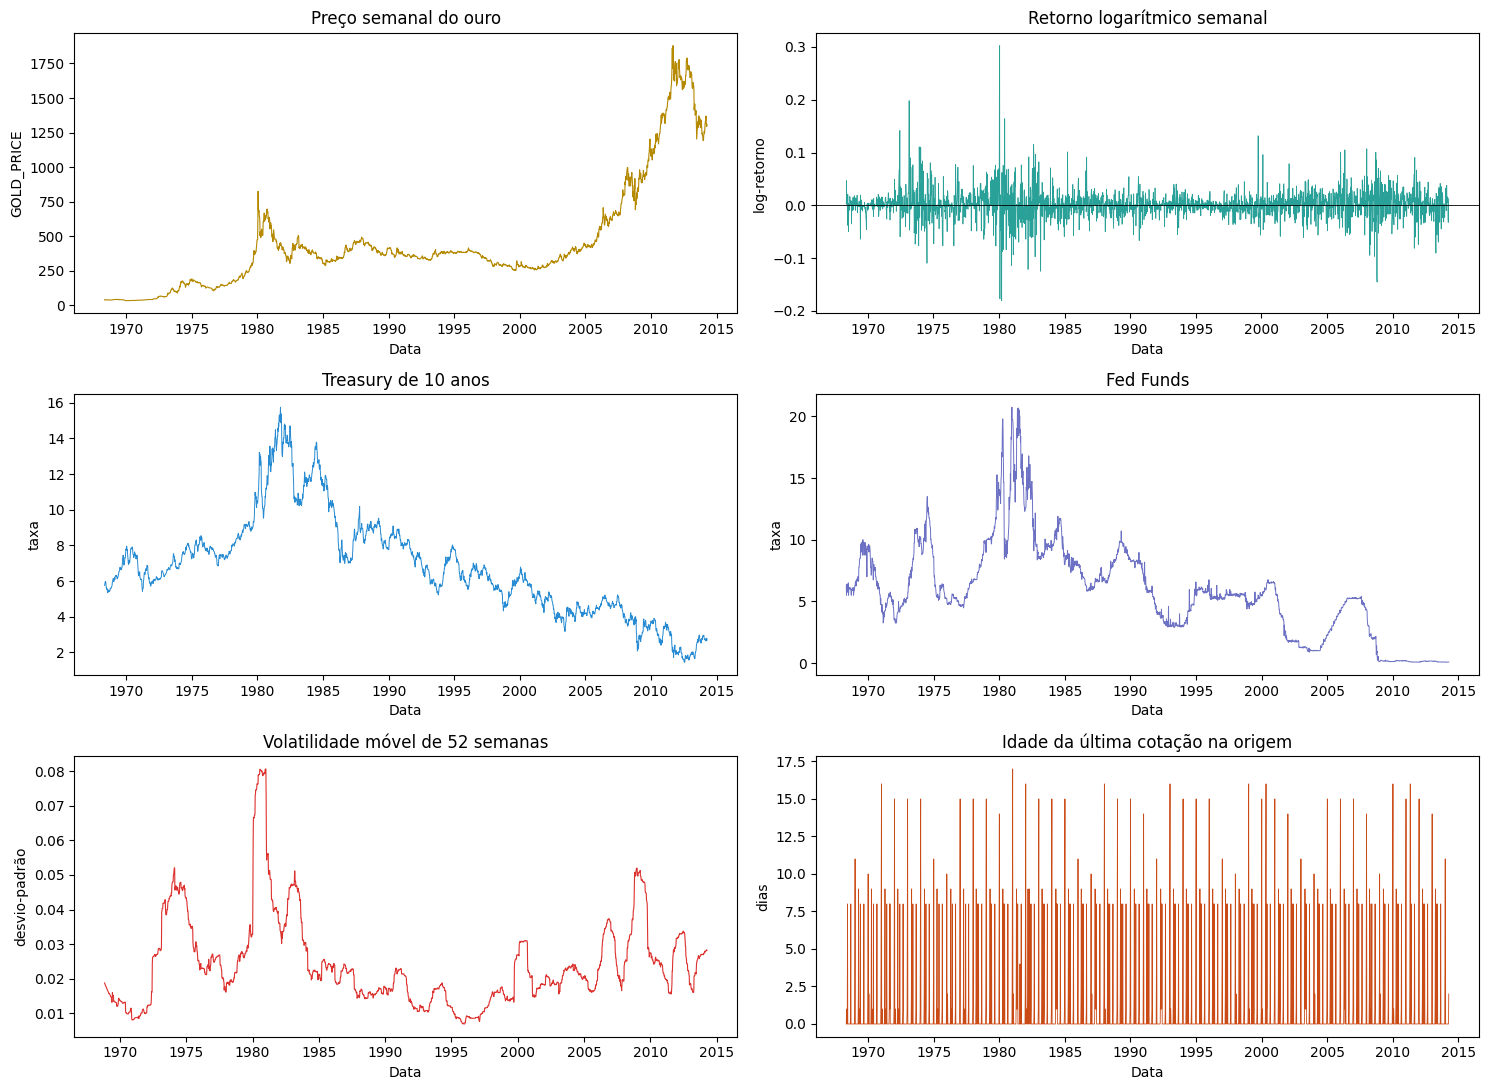

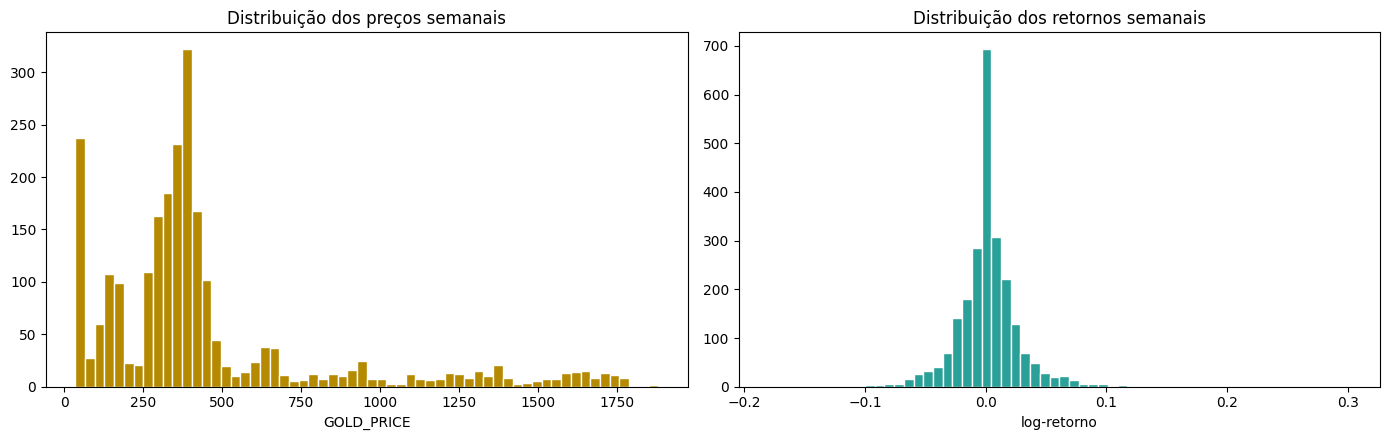

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#2aa198')
axes[0, 1].axhline(0, color='black', lw=.6)
axes[0, 1].set(title='Retorno logarítmico semanal', ylabel='log-retorno')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#268bd2')
axes[1, 0].set(title='Treasury de 10 anos', ylabel='taxa')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds', ylabel='taxa')
axes[2, 0].plot(
    weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(),
    lw=.8, color='#dc322f',
)
axes[2, 0].set(title='Volatilidade móvel de 52 semanas', ylabel='desvio-padrão')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cb4b16')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat:
    ax.set_xlabel('Data')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços semanais', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#2aa198')
axes[1].set(title='Distribuição dos retornos semanais', xlabel='log-retorno')
plt.tight_layout(); plt.show()


## 4. STL e força da sazonalidade

A STL usa o preço semanal regular e período 52. A força sazonal é

\[
F_S = \max\left(0, 1 -
\frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right).
\]

Também calculamos a força da tendência pela fórmula análoga. A decomposição é
diagnóstica e não entra diretamente nas features.


,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendencia,0.979394,52


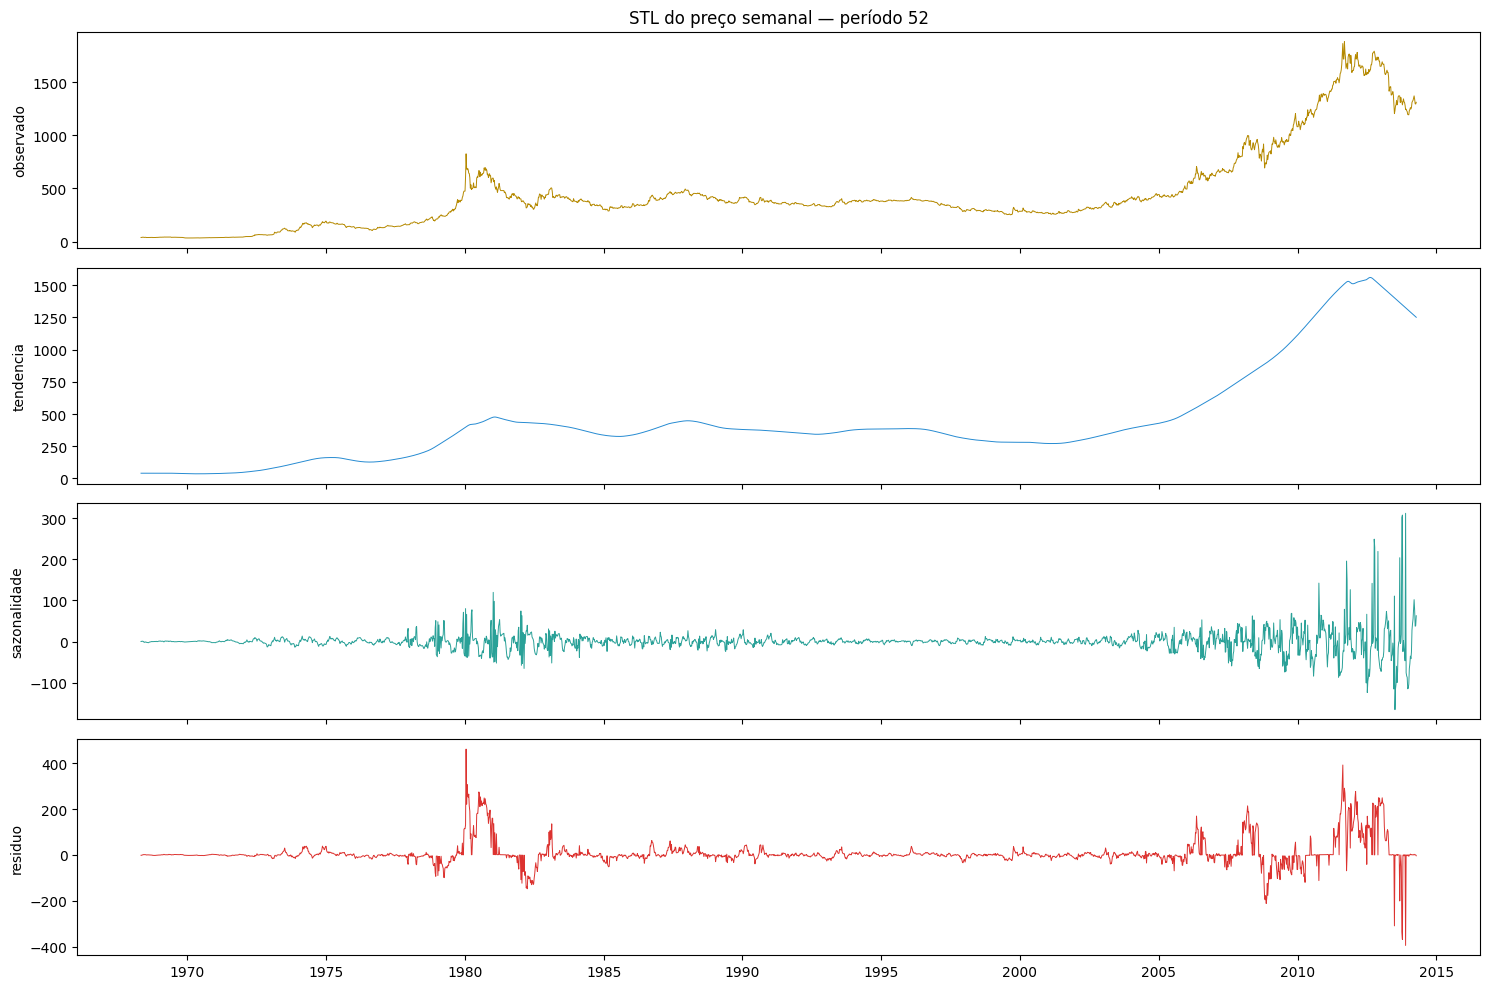

In [5]:
stl_series = weekly.set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
stl_components = pd.DataFrame({
    'observado': stl_result.observed,
    'tendencia': stl_result.trend,
    'sazonalidade': stl_result.seasonal,
    'residuo': stl_result.resid,
}, index=stl_series.index)

residual_variance = np.var(stl_result.resid, ddof=1)
seasonal_denominator = np.var(stl_result.seasonal + stl_result.resid, ddof=1)
trend_denominator = np.var(stl_result.trend + stl_result.resid, ddof=1)
seasonal_strength = max(0.0, 1.0 - residual_variance / seasonal_denominator)
trend_strength = max(0.0, 1.0 - residual_variance / trend_denominator)
strength_report = pd.DataFrame({
    'componente': ['sazonalidade', 'tendencia'],
    'forca': [seasonal_strength, trend_strength],
    'periodo_stl': [STL_PERIOD, STL_PERIOD],
})
display(strength_report)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
for ax, column, color in zip(
    axes, stl_components.columns, ['#b58900', '#268bd2', '#2aa198', '#dc322f']
):
    ax.plot(stl_components.index, stl_components[column], lw=.7, color=color)
    ax.set_ylabel(column)
axes[0].set_title('STL do preço semanal — período 52')
plt.tight_layout(); plt.show()


## Síntese verificada

- CSV: 9.864 linhas, 16 colunas, sem nulos e sem datas duplicadas.
- Período diário: 1968-04-29 a 2014-04-09.
- Série: 2.398 semanas regulares, de 1968-05-03 a 2014-04-11.
- Semanas sem linha de origem: 254; idade máxima da cotação: 17 dias.
- Força sazonal: `0,0000`; força da tendência: `0,9794`.
- `TARGET` e as demais colunas derivadas do CSV não são usadas na preparação.
